In [45]:
!pip install tensorflow matplotlib
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)
import matplotlib.pyplot as plt

In [46]:
train_dir = r"D:\pics\wrok\Python CNN\archive\train"
valid_dir = r"D:\pics\wrok\Python CNN\archive\valid"
test_dir = r"D:\pics\wrok\Python CNN\archive\test"

In [47]:
train_datagen = ImageDataGenerator(
    rescale=1./255
)

valid_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

valid_data = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 1470 images belonging to 3 classes.
Found 420 images belonging to 3 classes.
Found 210 images belonging to 3 classes.


In [43]:
print("Class Mapping:")
print(train_data.class_indices)

Class Mapping:
{'dark': 0, 'fair': 1, 'light': 2}


In [ ]:
model = Sequential()

# First CNN Layer
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(224,224,3)
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Second CNN Layer
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Third CNN Layer
model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Convert feature maps into 1D
model.add(Flatten())

# Dense Layer
model.add(Dense(
    128,
    activation='relu'
))

# Reduce overfitting
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(
    train_data.num_classes,
    activation='softmax'
))

In [ ]:
model.summary()

In [12]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=15
)

Epoch 1/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 71s 1s/step - accuracy: 0.4762 - loss: 1.1446 - val_accuracy: 0.6881 - val_loss: 0.6738
Epoch 2/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 37s 801ms/step - accuracy: 0.6639 - loss: 0.7417 - val_accuracy: 0.6548 - val_loss: 0.7238
Epoch 3/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 38s 827ms/step - accuracy: 0.7136 - loss: 0.6329 - val_accuracy: 0.7595 - val_loss: 0.5386
Epoch 4/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 38s 814ms/step - accuracy: 0.7354 - loss: 0.5970 - val_accuracy: 0.7762 - val_loss: 0.4983
Epoch 5/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 36s 784ms/step - accuracy: 0.7605 - loss: 0.5493 - val_accuracy: 0.7095 - val_loss: 0.5516
Epoch 6/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 36s 787ms/step - accuracy: 0.7680 - loss: 0.4976 - val_accuracy: 0.8000 - val_loss: 0.4566
Epoch 7/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 36s 783ms/step - accuracy: 0.7986 - loss: 0.4800 - val_accuracy: 0.8024 - val_loss: 0.4430
Epoch 8/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 37s 792ms/step - accuracy: 0.8449 - loss: 0.3868 - val_accurac

In [14]:
loss, accuracy = model.evaluate(test_data)

print(f"Test Accuracy: {accuracy*100:.2f}%")

7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 750ms/step - accuracy: 0.8143 - loss: 0.6881
Test Accuracy: 81.43%


In [35]:
model.save("skin_tone_model.h5")

print("Model Saved Successfully")

Model Saved Successfully


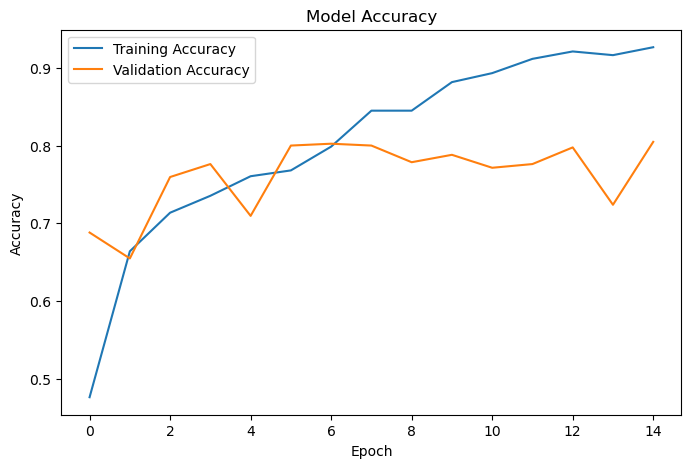

In [36]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend([
    'Training Accuracy',
    'Validation Accuracy'
])

plt.show()

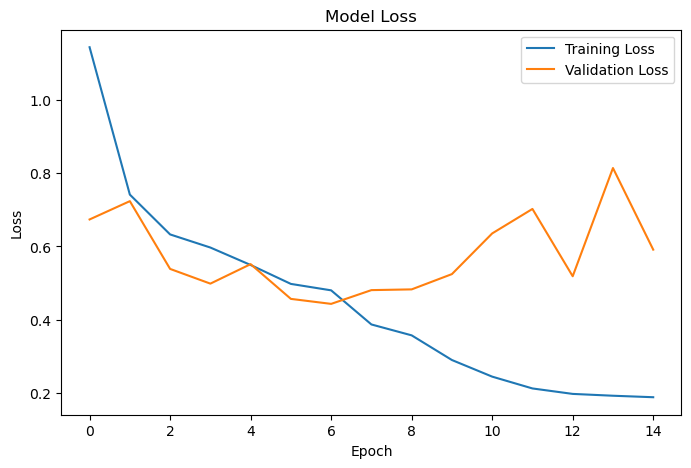

In [37]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend([
    'Training Loss',
    'Validation Loss'
])

plt.show()

In [40]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = r"D:\pics\wrok\Python CNN\draw3.png"

img = image.load_img(
    r"D:\pics\wrok\Python CNN\draw3.png",
    target_size=(224,224)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

labels = {
    v:k for k,v in train_data.class_indices.items()
}

print("Predicted Skin Tone:",
      labels[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Predicted Skin Tone: fair


In [42]:
print(train_data.class_indices)

{'dark': 0, 'fair': 1, 'light': 2}
